# matplotlib objects as nested dictionaries

As discussed in the class page, `matplotlib` objects have the follow main classes with associated attributes:

* `Figure` - subplots, dpi, size_inches, suptitle
* `Subplot` - row, col, title, xaxis, yaxis, legend, colorbar, lines, collections, patches, images, texts
* `Line2D` - linecolor, linestyle, xdata, ydata
* `Image` - position, size, array, colormap
* `Patch` - type, position, size, facecolor, edgecolor
* `Collection` - type, position, size, facecolor, edgecolor
* `Axis` - ticklabels, ticklocs, label
* `Legend` - position, handles, labels, title
* `Colorbar` - position, ticklocs, ticklabels, title, colormap
* `Text` - text, position, color, fontsize, fontname, fontstyle

Note that this listing is no where near comprehensive and is designed to serve as an abbreviated description of the `matplotlib` class hierarchy. 

The `Figure`, `Subplot`, and `Text` classes encode the formatting of the plot while the `Axis`, `Colorbar`, and `Legend` class defines guides that help the user interpret the content of the plot. Finally, the `Line2D`, `Patch`, `Collection`, and `Image` class represent the visual contents of the plot.

The file `mpl_converter.py` in the `examples` directory implements a function`obj_to_dict()` that convertes objects of these types into an equivalent dictionary whose keys correspond to the associated attribute.  This notebook contains five examples of `matplotlib` objects converted into this dictionary form.

In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np
import pprint
import mpl_converter

## Empty figure

In [2]:
def plot_empty_figure():
    """
    Output: empty matplotlib figure"
    """
    return plt.figure()

In [3]:
fig1 = plot_empty_figure()
print(mpl_converter.obj_to_dict(fig1))

{'subplots': [], 'dpi': 100.0, 'size_inches': [6.4, 4.8]}


<Figure size 640x480 with 0 Axes>

In its most basic form, a `Figure` consists of a list of `Subplot` objects. In this case, there are no subplots so the list is empty.

## Column of three simple subplots

In [4]:
def plot_simple_array():
    """
    Output: matplotlib figure consisting of column of three simple subplots
    """
    
    fig, (ax0, ax1, ax2) = plt.subplots(3, 1)
    fig.set_size_inches(4, 8)
    ax0.plot([0, 1, 2])
    ax1.set_axis_off()
    return fig

{'dpi': 100.0, 'size_inches': [4.0, 8.0], 'subplots': [<Axes: >, <Axes: >, <Axes: >]}


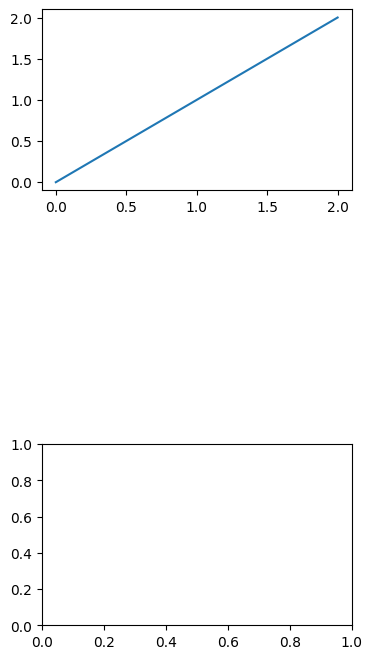

In [5]:
fig2 = plot_simple_array()
fig2.canvas.draw()
pprint.pprint(mpl_converter.obj_to_dict(fig2), width=100, compact=True)

These `Subplot` objects form a 2D array of subplots. The `row` and `col` attributes indicate the location of the subplot in the array. The first subplot includes a `Line2D` object that contains the data for the subplot while the second subplot is entirely empty since the axes are set to off and it contains no data.  

Note that we have used the `pprint` module to improve the format of the printed dictionary.

## Plot  of two hat functions

In [6]:
def plot_lines(data1, data2):
    """
    Input: Lists data1, data2 of floats
    
    Output: matplotlib figure of consisting of two line plots
    plus a legend and some text using matplotlib
    """

    fig, ax0 = plt.subplots()
    ax0.set_title("Plot of two hat functions")
    ax0.plot(data1, "r", label="Red plot")
    ax0.plot(data2, "--", label="Green plot")
    ax0.legend(title="A legend", loc=[0.0, 0.4])
    ax0.set_xlabel("X-axis label")
    ax0.set_ylabel("Y-axis label")
    ax0.set_yticks([0, 2])
    ax0.text(2.5, 0.1, "Rated 8.7 on IMDB", fontsize=8)
    return fig

{'dpi': 100.0,
 'size_inches': [6.4, 4.8],
 'subplots': [<Axes: title={'center': 'Plot of two hat functions'}, xlabel='X-axis label', ylabel='Y-axis label'>]}


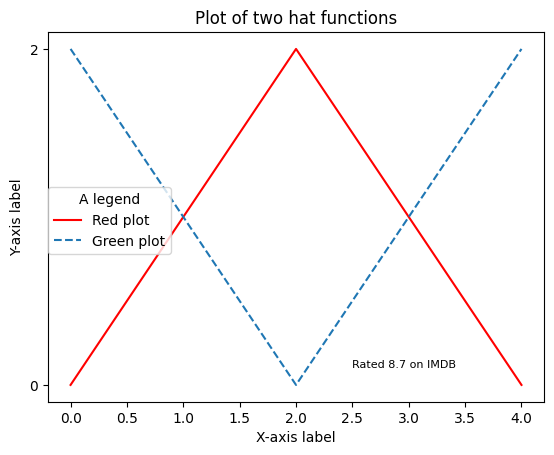

In [7]:
data1 = [0, 1, 2, 1, 0]
data2 = [2, 1, 0, 1, 2]
fig3 = plot_lines(data1, data2)
fig3.canvas.draw()
pprint.pprint(mpl_converter.obj_to_dict(fig3), width=100, compact=True)

This example includes two `Line2D` objects as well as a `Legend` object.

## `plot_distribution()` from week 2

In [8]:
def compute_distribution(flips, trials, seed=None):
    """
    Input: Integers flips, trials, optional integer seed
    
    Output: List of integers of length trials, generated via fliping a coin flips times
    
    NOTE: seed is used to initialize the random number generate for deterministic testing
    """ 
    
    if seed:
        random.seed(seed)
        
    distribution = []
    for dummy_trial in range(trials):
        heads = 0
        for dummy in range(flips):
            if random.randrange(2) == 0:
                heads += 1
        distribution.append(heads)
    
    return distribution

In [9]:
def plot_distribution(distribution, num_bins, title="Binomial distribution"):
    """
    Input: List distribution of integers, integer num_bins, optional string title
    
    Output: matplotlib figure containing histogram of distribution with specified 
    number of bins and provided title
    """
    bin_boundaries = [-0.5 + idx for idx in range(num_bins + 1)]
    
    fig = plt.figure()
    plt.hist(distribution, bin_boundaries)
    plt.title(title)
    plt.xlabel("Number of heads")
    plt.ylabel("Number of trials")
    return fig

{'dpi': 100.0,
 'size_inches': [6.4, 4.8],
 'subplots': [<Axes: title={'center': 'Binomial distribution with flips=4 and trials=10'}, xlabel='Number of heads', ylabel='Number of trials'>]}


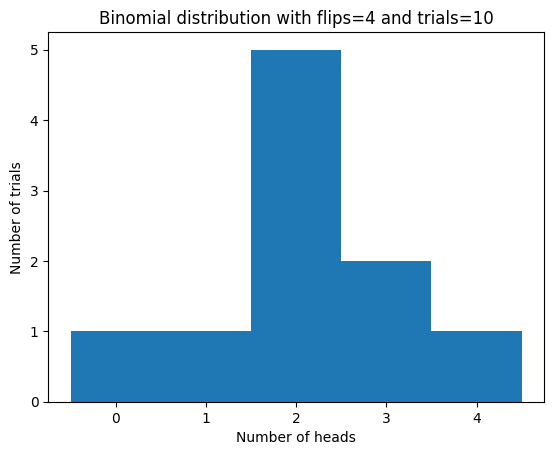

In [10]:
dist_4_10 = compute_distribution(4, 10, seed=1)
fig4 = plot_distribution(dist_4_10, 5, title="Binomial distribution with flips=4 and trials=10")
fig4.canvas.draw()
pprint.pprint(mpl_converter.obj_to_dict(fig4), width=120, compact=True)    

This example from week 2 includes five `Rectangle` objects generated by `plt.hist()`.  Note the rectangles' position are stored in `data` coordinates.  On the other hand, the position of the title and axes labels are stored in `figure` coordinates.

## Row of interesting subplots

In [11]:
def plot_row_subplots():
    """
    Output: matplotlib figure consisting of a row of subplots
    """

    N = 5
    x0 = np.linspace(0, 2 * np.pi, N)
    y0 = np.sin(x0 ** 2)
    np.random.seed(1)
    x1 = np.round(np.random.rand(N), 3)
    y1 = np.round(np.random.rand(N), 3)
    s1 = np.round(300 * np.random.rand(N) ** 2 + 300, 3)
    c1 = np.round(np.random.rand(N), 3)
    xy3 = [[0, 1, 2, 3], [3, 4, 5, 6], [6, 7, 8, 9]]

    fig, (ax0, ax1, ax2) = plt.subplots(1, 3)
    ax0.plot(x0, y0, "r--")
    ax0.set_title("Line plot", color="green")
    ax0.set_xlabel("Label for x-axis on line plot", color="red")
    ax0.set_ylabel("Label for y-axis on line plot", color="blue")
    ax1.scatter(x1, y1, s=s1, c=c1)
    ax1.set_title("Scatter plot")
    ax2.imshow(xy3)
    ax2.set_title("Image plot")
    fig.suptitle('Suptitle for three subplots in a row')
    fig.set_size_inches(18, 4)

    return fig

{'dpi': 100.0,
 'size_inches': [18.0, 4.0],
 'subplots': [<Axes: title={'center': 'Line plot'}, xlabel='Label for x-axis on line plot', ylabel='Label for y-axis on line plot'>,
              <Axes: title={'center': 'Scatter plot'}>, <Axes: title={'center': 'Image plot'}>],
 'suptitle': {'fontsize': 12.0, 'position': [0.5, 0.98], 'text': 'Suptitle for three subplots in a row'}}


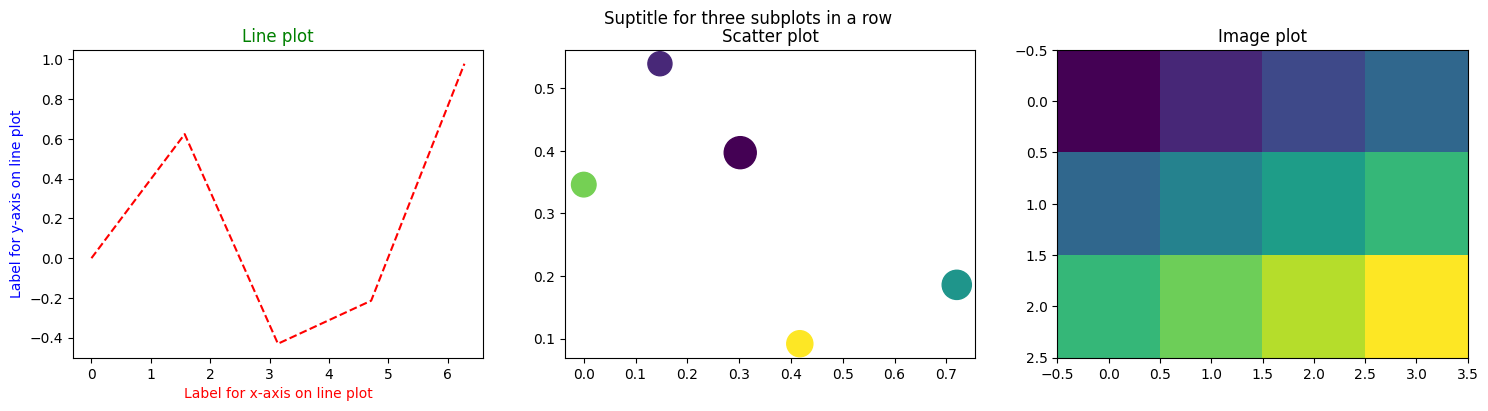

In [12]:
fig5 = plot_row_subplots()
fig5.canvas.draw()
pprint.pprint(mpl_converter.obj_to_dict(fig5), width=130, compact=True)

One final example of a row of subplots including various types of plots.  Note that this example also includes a `suptitle` that spans all three subplots.